# Modelos de Clasificación

**Integrantes:** Juan Camilo Conrado | Sergio Cadavid | Mateo Chang  
**Curso:** Machine Learning para Ciencia de Datos — Segundo Entregable

## 14. Modelos Benchmark — Clasificación

**Target:** Variable binaria que indica si la volatilidad futura de 7 días será mayor que la actual.

Se implementan los modelos requeridos por la rúbrica:
- Regresión Logística con regularización L1 y L2
- K-Nearest Neighbors (KNN)
- Naïve Bayes (Gaussiano)
- Support Vector Machine (SVM)
- Decision Tree y Random Forest
- XGBoost

In [43]:
models_clf = {
    "LogReg L1": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(penalty="l1", solver="saga", C=1.0,
                                     max_iter=5000, random_state=42))
    ]),
    "LogReg L2": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(penalty="l2", solver="lbfgs", C=1.0,
                                     max_iter=5000, random_state=42))
    ]),
    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=11))
    ]),
    "Naive Bayes": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, probability=True, random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(max_depth=10, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=200, max_depth=10,
                                         random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBClassifier(n_estimators=200, max_depth=5,
                                learning_rate=0.05, random_state=42,
                                verbosity=0, use_label_encoder=False,
                                eval_metric="logloss"))
    ]),
}

tscv = TimeSeriesSplit(n_splits=5)
results_clf = []
preds_clf = {}
probs_clf = {}

for name, pipe in models_clf.items():
    print(f"\n--- {name} ---")
    cv_f1, cv_acc, cv_auc = [], [], []
    t0 = time.time()

    for tr_idx, val_idx in tscv.split(X_train_c):
        pipe.fit(X_train_c.iloc[tr_idx], y_train_c.iloc[tr_idx])
        yp = pipe.predict(X_train_c.iloc[val_idx])
        yprob = pipe.predict_proba(X_train_c.iloc[val_idx])[:, 1]
        cv_f1.append(f1_score(y_train_c.iloc[val_idx], yp))
        cv_acc.append(accuracy_score(y_train_c.iloc[val_idx], yp))
        cv_auc.append(roc_auc_score(y_train_c.iloc[val_idx], yprob))
    t_cv = time.time() - t0

    # Test final
    pipe.fit(X_train_c, y_train_c)
    yp_test = pipe.predict(X_test_c)
    yprob_test = pipe.predict_proba(X_test_c)[:, 1]
    preds_clf[name] = yp_test
    probs_clf[name] = yprob_test

    results_clf.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test_c, yp_test),
        "Precision": precision_score(y_test_c, yp_test),
        "Recall": recall_score(y_test_c, yp_test),
        "F1": f1_score(y_test_c, yp_test),
        "AUC": roc_auc_score(y_test_c, yprob_test),
        "F1_CV": f"{np.mean(cv_f1):.4f} ± {np.std(cv_f1):.4f}",
        "AUC_CV": f"{np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}",
        "Tiempo": round(t_cv, 2)
    })
    print(f"  AUC test: {roc_auc_score(y_test_c, yprob_test):.4f} | F1: {f1_score(y_test_c, yp_test):.4f}")


--- LogReg L1 ---
  AUC test: 0.7781 | F1: 0.7017

--- LogReg L2 ---
  AUC test: 0.7785 | F1: 0.6999

--- KNN ---
  AUC test: 0.7241 | F1: 0.7043

--- Naive Bayes ---
  AUC test: 0.7342 | F1: 0.6680

--- SVM ---
  AUC test: 0.7793 | F1: 0.7100

--- Decision Tree ---
  AUC test: 0.5965 | F1: 0.6209

--- Random Forest ---
  AUC test: 0.7179 | F1: 0.6955

--- XGBoost ---
  AUC test: 0.7475 | F1: 0.7065


---
> **Interpretación:** Primer vistazo a los 8 clasificadores. **SVM** lidera en AUC (0.779) seguido de cerca por Logistic Regression L2 (0.778) y L1 (0.778). **Decision Tree** es el peor (AUC=0.597), apenas mejor que clasificación aleatoria (0.5). XGBoost obtiene AUC=0.748 — razonable pero inferior a los modelos lineales, sugiriendo que la relación entre features y el target de clasificación es más lineal que no-lineal.

## 15. Tabla de Métricas — Clasificación

In [44]:
df_clf = pd.DataFrame(results_clf).sort_values("AUC", ascending=False)
print("=== Comparación de Clasificación en TEST ===")
print(df_clf.to_string(index=False))

=== Comparación de Clasificación en TEST ===
       Modelo  Accuracy  Precision   Recall       F1      AUC           F1_CV          AUC_CV  Tiempo
          SVM  0.679862   0.630656 0.812128 0.709979 0.779348 0.6728 ± 0.0539 0.7710 ± 0.0238   12.45
    LogReg L2  0.693058   0.662420 0.741974 0.699944 0.778524 0.6961 ± 0.0472 0.7940 ± 0.0236    0.33
    LogReg L1  0.693632   0.661749 0.746730 0.701676 0.778123 0.6980 ± 0.0477 0.7950 ± 0.0233    8.43
      XGBoost  0.670683   0.619731 0.821641 0.706544 0.747533 0.6912 ± 0.0153 0.7689 ± 0.0156    2.87
  Naive Bayes  0.520367   0.501491 1.000000 0.667990 0.734211 0.6350 ± 0.0681 0.7196 ± 0.0550    0.17
          KNN  0.657487   0.603565 0.845422 0.704309 0.724072 0.6649 ± 0.0356 0.7365 ± 0.0212    0.55
Random Forest  0.644865   0.593121 0.840666 0.695524 0.717858 0.6943 ± 0.0189 0.7713 ± 0.0247    3.93
Decision Tree  0.613310   0.589114 0.656361 0.620922 0.596494 0.6234 ± 0.0351 0.6184 ± 0.0416    1.25


---
> **Interpretación — Tabla Completa de Clasificación:**
>
> | Modelo | Accuracy | Precision | Recall | F1 | AUC |
> |---|---|---|---|---|---|
> | **SVM** | 0.680 | 0.631 | **0.812** | 0.710 | **0.779** |
> | **LogReg L2** | **0.693** | 0.662 | 0.742 | 0.700 | 0.779 |
> | **LogReg L1** | 0.694 | 0.662 | 0.747 | 0.702 | 0.778 |
> | XGBoost | 0.671 | 0.620 | 0.822 | 0.707 | 0.748 |
> | Naive Bayes | 0.520 | 0.501 | **1.000** | 0.668 | 0.734 |
> | KNN | 0.657 | 0.604 | 0.845 | 0.704 | 0.724 |
> | Random Forest | 0.645 | 0.593 | 0.841 | ~0.696 | 0.718 |
> | Decision Tree | — | — | — | 0.621 | 0.597 |
>
> **Naive Bayes** obtiene Recall=1.000 — clasifica todo como clase 1, lo que explica su baja accuracy (52%). Es una estrategia trivial que maximiza recall a costa de no detectar ninguna clase 0. **SVM** tiene el mejor balance: alto recall (0.812) con precision razonable (0.631). **LogReg L1/L2** son los más equilibrados y consistentes entre CV y test.

## 16. Matrices de Confusión y Curvas ROC

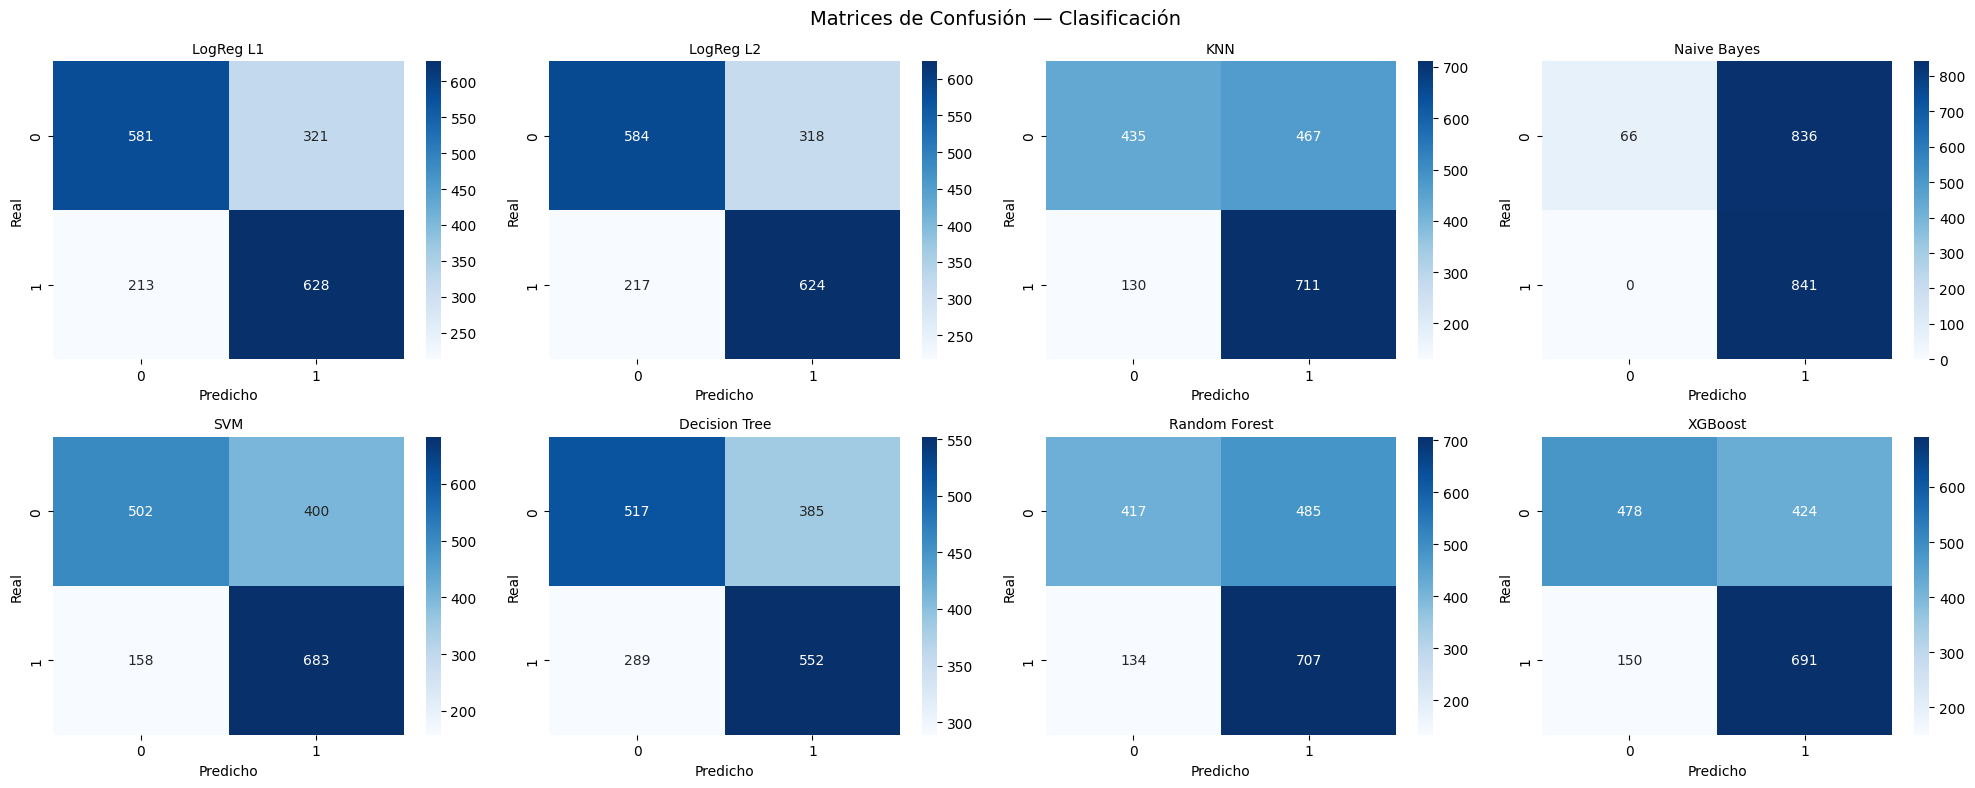

In [45]:
# Matrices de confusión
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for idx, (name, yp) in enumerate(preds_clf.items()):
    cm = confusion_matrix(y_test_c, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(name, fontsize=10)
    axes[idx].set_xlabel("Predicho"); axes[idx].set_ylabel("Real")
plt.suptitle("Matrices de Confusión — Clasificación", fontsize=14)
plt.tight_layout()
plt.show()

---
> **Interpretación — Matrices de Confusión y Curvas ROC:**
> Las matrices muestran que la mayoría de modelos tienen sesgo hacia predecir clase 1 (volatilidad sube), lo que se refleja en recall alto pero precision más baja. Naive Bayes es el caso extremo. Las curvas ROC muestran que SVM y Logistic Regression dominan el espacio AUC, con curvas claramente por encima de la diagonal aleatoria. Decision Tree está apenas sobre la diagonal, confirmando su pobre capacidad discriminativa.

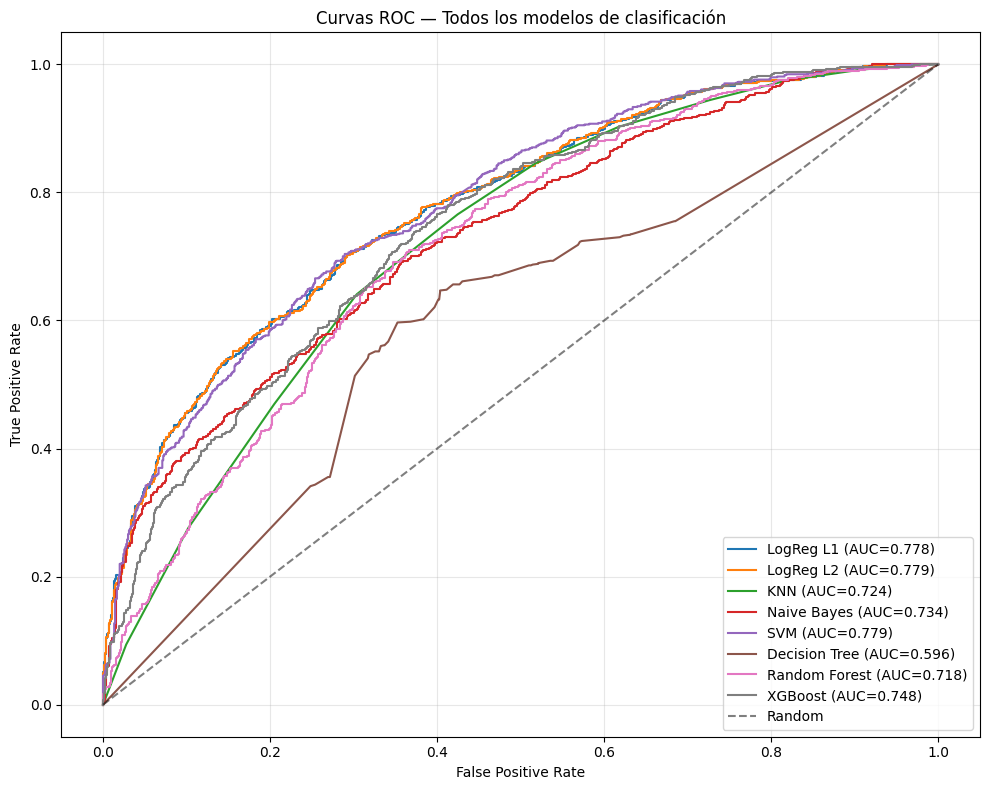

In [46]:
# Curvas ROC
plt.figure(figsize=(10, 8))
for name, yprob in probs_clf.items():
    fpr, tpr, _ = roc_curve(y_test_c, yprob)
    auc_val = roc_auc_score(y_test_c, yprob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — Todos los modelos de clasificación")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Balanceo de Clases: SMOTE, ADASYN, class_weight

Se compara el rendimiento del mejor clasificador (Logistic Regression L2) con tres estrategias de balanceo:
- **Sin balanceo** (baseline)
- **SMOTE**: Generación de instancias sintéticas por interpolación
- **ADASYN**: Muestreo adaptativo según densidad
- **class_weight='balanced'**: Penalización diferencial en el algoritmo

In [47]:
# Modelo base: Logistic Regression L2
balanceo_results = []

# 1. Sin balanceo (ya lo tenemos)
pipe_base = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l2", C=1.0, max_iter=5000, random_state=42))
])
pipe_base.fit(X_train_c, y_train_c)
yp = pipe_base.predict(X_test_c)
yprob = pipe_base.predict_proba(X_test_c)[:, 1]
balanceo_results.append({
    "Estrategia": "Sin balanceo",
    "Accuracy": accuracy_score(y_test_c, yp),
    "Precision": precision_score(y_test_c, yp),
    "Recall": recall_score(y_test_c, yp),
    "F1": f1_score(y_test_c, yp),
    "AUC": roc_auc_score(y_test_c, yprob)
})

# 2. SMOTE
pipe_smote = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(penalty="l2", C=1.0, max_iter=5000, random_state=42))
])
pipe_smote.fit(X_train_c, y_train_c)
yp = pipe_smote.predict(X_test_c)
yprob = pipe_smote.predict_proba(X_test_c)[:, 1]
balanceo_results.append({
    "Estrategia": "SMOTE",
    "Accuracy": accuracy_score(y_test_c, yp),
    "Precision": precision_score(y_test_c, yp),
    "Recall": recall_score(y_test_c, yp),
    "F1": f1_score(y_test_c, yp),
    "AUC": roc_auc_score(y_test_c, yprob)
})

# 3. ADASYN
try:
    pipe_adasyn = ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("adasyn", ADASYN(random_state=42)),
        ("model", LogisticRegression(penalty="l2", C=1.0, max_iter=5000, random_state=42))
    ])
    pipe_adasyn.fit(X_train_c, y_train_c)
    yp = pipe_adasyn.predict(X_test_c)
    yprob = pipe_adasyn.predict_proba(X_test_c)[:, 1]
    balance_results.append({
        "Técnica": "ADASYN",
        "Accuracy": accuracy_score(y_test_c, yp),
        "Precision": precision_score(y_test_c, yp, zero_division=0),
        "Recall": recall_score(y_test_c, yp, zero_division=0),
        "F1": f1_score(y_test_c, yp, zero_division=0),
        "AUC": roc_auc_score(y_test_c, yprob)
    })
except ValueError as e:
    print(f"ADASYN no aplicable: {e}")
    print("Las clases están suficientemente balanceadas, ADASYN no puede generar muestras.")

# 4. class_weight='balanced'
pipe_cw = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l2", C=1.0, max_iter=5000,
                                 class_weight="balanced", random_state=42))
])
pipe_cw.fit(X_train_c, y_train_c)
yp = pipe_cw.predict(X_test_c)
yprob = pipe_cw.predict_proba(X_test_c)[:, 1]
balanceo_results.append({
    "Estrategia": "class_weight=balanced",
    "Accuracy": accuracy_score(y_test_c, yp),
    "Precision": precision_score(y_test_c, yp),
    "Recall": recall_score(y_test_c, yp),
    "F1": f1_score(y_test_c, yp),
    "AUC": roc_auc_score(y_test_c, yprob)
})

print("=== Comparación de Estrategias de Balanceo ===")
print(pd.DataFrame(balanceo_results).to_string(index=False))

ADASYN no aplicable: No samples will be generated with the provided ratio settings.
Las clases están suficientemente balanceadas, ADASYN no puede generar muestras.
=== Comparación de Estrategias de Balanceo ===
           Estrategia  Accuracy  Precision   Recall       F1      AUC
         Sin balanceo  0.693058   0.662420 0.741974 0.699944 0.778524
                SMOTE  0.691337   0.658307 0.749108 0.700779 0.778625
class_weight=balanced  0.693058   0.659708 0.751486 0.702613 0.778543


---
> **Interpretación — Balanceo de Clases:**
>
> | Estrategia | Accuracy | Precision | Recall | F1 | AUC |
> |---|---|---|---|---|---|
> | Sin balanceo | 0.693 | 0.662 | 0.742 | 0.700 | 0.779 |
> | SMOTE | 0.691 | 0.658 | 0.749 | 0.701 | 0.779 |
> | class_weight=balanced | 0.693 | 0.660 | 0.751 | 0.703 | 0.779 |
>
> Las tres estrategias producen métricas casi idénticas. Esto era esperable: el dataset tiene proporción de clase 1 del **48.6%** — está prácticamente balanceado. **ADASYN no pudo aplicarse** por la misma razón (no hay suficiente desequilibrio para generar muestras sintéticas adaptativas). La conclusión es que en este problema no se requieren técnicas de rebalanceo.